# The Postdoctoral Job Market as a Stable Matching Problem

## Background: The Gale-Shapley Algorithm

In 1962, David Gale and Lloyd Shapley introduced a beautiful solution to the **stable matching problem**: given two groups of agents — say, applicants and jobs — each with ranked preferences over the other side, how do you pair them so that the result is *stable*?

A matching is **stable** if there is no pair (applicant $a$, job $j$) such that:
- $a$ prefers $j$ to their current match, **and**
- $j$ prefers $a$ to their current match.

Such a pair is called a **blocking pair** — they would both rather be matched to each other, so any matching containing them is inherently unstable.

Gale and Shapley proved that a stable matching **always exists**, and gave an algorithm to find one. The algorithm is beautifully simple:

---

### The Deferred Acceptance Algorithm (applicant-proposing version)

1. Each applicant proposes to their most preferred job that hasn't yet rejected them.
2. Each job **tentatively** holds the best proposal it has received so far, and rejects all others.
3. Rejected applicants move to their next choice. Repeat until no one is rejected.

The word *deferred* is key: jobs hold offers tentatively, not finally. A job can drop an applicant it previously held if a better one arrives.

This is **applicant-optimal**: every applicant gets the best stable partner they could possibly get. By symmetry there is also a **job-proposing** version that is job-optimal (and applicant-pessimal).

---

### Why does this matter for the postdoc market?

The real postdoc market is *not* a clean Gale-Shapley process — offers are made sequentially over multiple rounds, applicants can hold multiple offers, and information is incomplete. But GS gives us a useful **theoretical benchmark**: what would the outcome look like if the market were perfectly coordinated? 

Comparing GS outcomes to our simulation outcomes reveals how much the market's friction (incomplete information, sequential offers, second calls) costs applicants and institutions.

# This isn't really working

## Setup

We use the same parameters as our simulation:

| Parameter | Value |
|---|---|
| Students applying | 750 (75% of 1000) |
| Postdocs re-applying | 100 (33% of 300) |
| Positions | 256 (6 top-tier, 50 mid-tier, 200 lower-tier) |
| Student skill | $\mathcal{N}(0, 1)$ |
| Postdoc skill | $\mathcal{N}(1.3, 0.8)$ (shifted up — they have a track record) |

Two design choices are needed to adapt GS to this setting:

**Applicant preference lists** are built the same way as in our simulation: each applicant applies to $k$ jobs chosen via a softmax over prestige, weighted by their self-awareness. A highly skilled applicant targets prestigious jobs; a lower-ranked applicant applies more broadly. We treat the chosen jobs as the applicant's preference list, ranked by prestige (with a small noise term to reflect genuine uncertainty about fit).

**Job preference lists** are built using the same Mallows model as in our simulation: a stochastic perturbation of the true skill ranking. This captures the fact that search committees don't perfectly evaluate candidates.

In [10]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

np.random.seed(42)

# ── Market parameters (matching the simulation) ───────────────────────────
N_STUDENTS            = 1000
N_POSTDOCS            = 300
FRAC_STUDENT_APPLYING = 3 / 4
FRAC_POSTDOC_APPLYING = 1 / 3
SPLITS                = [6, 50, 200]          # positions per tier
TIER_MAX_PRESTIGE     = [10, 15, 2]
PRESTIGE_DECAYS       = [1, 5, 1.2]
MINIMUM_PRESTIGES     = [5, 4, 1]
MEAN_APPLICATIONS     = np.log(30)
SIGMA_APPLICATIONS    = 0.4
LOC_STUDENT           = 0.0
SCALE_STUDENT         = 1.0
LOC_POSTDOC           = 1.3
SCALE_POSTDOC         = 0.8
SELF_AWARENESS        = 0.5
STOCHASTICITY         = 0.76     # Mallows phi

N_STUDENT_APPLYING    = int(N_STUDENTS * FRAC_STUDENT_APPLYING)
N_POSTDOC_APPLYING    = int(N_POSTDOCS * FRAC_POSTDOC_APPLYING)
N_POSITIONS           = sum(SPLITS)

print(f"Students applying  : {N_STUDENT_APPLYING}")
print(f"Postdocs applying  : {N_POSTDOC_APPLYING}")
print(f"Total applicants   : {N_STUDENT_APPLYING + N_POSTDOC_APPLYING}")
print(f"Total positions    : {N_POSITIONS}")
print(f"Fill rate (if all match): {N_POSITIONS / (N_STUDENT_APPLYING + N_POSTDOC_APPLYING):.1%}")

Students applying  : 750
Postdocs applying  : 100
Total applicants   : 850
Total positions    : 256
Fill rate (if all match): 30.1%


## Step 1 — Draw skills and rank applicants

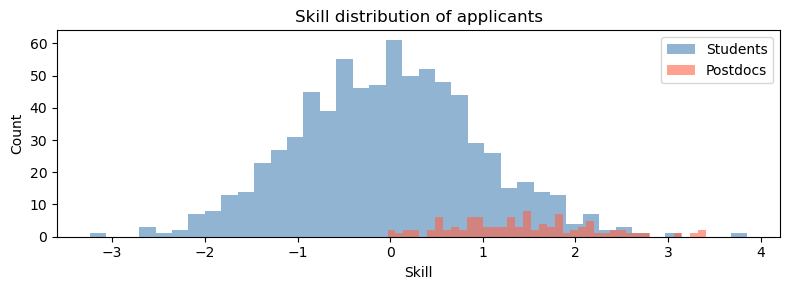

Postdoc skill advantage: 1.41 vs -0.02 (students)


In [11]:
def draw_skills():
    skills_s = np.random.normal(LOC_STUDENT, SCALE_STUDENT, N_STUDENT_APPLYING)
    skills_p = np.random.normal(LOC_POSTDOC, SCALE_POSTDOC, N_POSTDOC_APPLYING)
    skills   = np.concatenate([skills_s, skills_p])
    labels   = ['student'] * N_STUDENT_APPLYING + ['postdoc'] * N_POSTDOC_APPLYING
    order    = np.argsort(-skills)          # best first
    return skills[order], [labels[i] for i in order]

skills, labels = draw_skills()
n_applicants   = len(skills)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(skills[[l == 'student' for l in labels]], bins=40,
        alpha=0.6, label='Students', color='steelblue')
ax.hist(skills[[l == 'postdoc' for l in labels]], bins=40,
        alpha=0.6, label='Postdocs', color='tomato')
ax.set_xlabel('Skill')
ax.set_ylabel('Count')
ax.set_title('Skill distribution of applicants')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Postdoc skill advantage: {skills[[l=='postdoc' for l in labels]].mean():.2f} "
      f"vs {skills[[l=='student' for l in labels]].mean():.2f} (students)")

## Step 2 — Build prestige values for each position

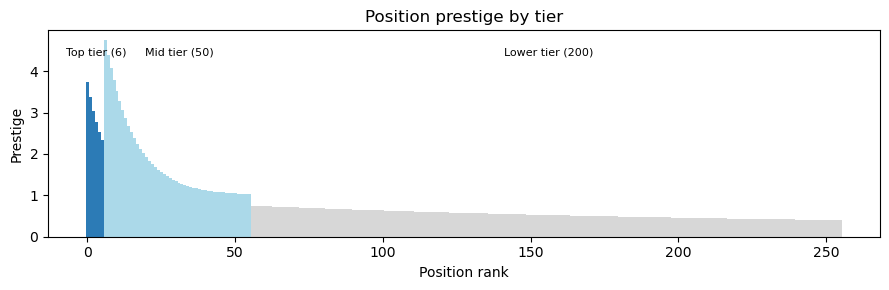

In [12]:
def build_prestige():
    vals = []
    for n, t_max, t_decay, t_min in zip(
        SPLITS, TIER_MAX_PRESTIGE, PRESTIGE_DECAYS, MINIMUM_PRESTIGES
    ):
        ranks = np.arange(n)
        vals.extend(t_max * np.exp(-t_decay / n * ranks) + t_min)
    return np.array(vals) / 4

prestige = build_prestige()

fig, ax = plt.subplots(figsize=(9, 3))
colors = (['#2c7bb6'] * SPLITS[0] +
          ['#abd9e9'] * SPLITS[1] +
          ['#d7d7d7'] * SPLITS[2])
ax.bar(range(N_POSITIONS), prestige, color=colors, width=1.0, linewidth=0)
ax.set_xlabel('Position rank')
ax.set_ylabel('Prestige')
ax.set_title('Position prestige by tier')
for label, color, x in zip(
    ['Top tier (6)', 'Mid tier (50)', 'Lower tier (200)'],
    ['#2c7bb6', '#abd9e9', '#d7d7d7'],
    [3, 31, 156]
):
    ax.text(x, prestige.max() * 0.92, label, ha='center',
            color='black', fontsize=8)
plt.tight_layout()
plt.show()

## Step 3 — Build preference lists

### Applicant preferences over jobs

Each applicant draws $k \sim \text{LogNormal}(\mu, \sigma)$ applications. They allocate these applications across jobs using a softmax over prestige, modulated by `self_awareness`: a high-skill applicant targets prestigious positions, a low-skill applicant applies more broadly (lower `beta` → flatter distribution). The $k$ chosen jobs are then ranked by prestige plus a small Gaussian noise term, reflecting genuine uncertainty about fit.

### Job preferences over applicants

Each job sees the applicants who applied to it. The *true* ranking is by skill descending, but the committee's evaluation is imperfect — modelled by a Mallows distribution with concentration parameter $\phi = 0.76$ ($\phi=0$ is pure skill order, $\phi=1$ is uniform random).

In [13]:
# ── Mallows sampler (reuses the same logic as the simulation) ─────────────
def mallows_rank(pool, phi):
    """Return a Mallows-perturbed ranking of `pool` (indices into skills).
    Reference = skill descending.  phi=0 -> skill order, phi=1 -> uniform."""
    if len(pool) == 0:
        return []
    if len(pool) == 1:
        return list(pool)
    # Mallows via insertion: build permutation element by element
    # P(insert at position j from right) ∝ phi^j
    ref = sorted(pool, key=lambda i: skills[i], reverse=True)
    result = [ref[0]]
    for k in range(1, len(ref)):
        # Weights: phi^0, phi^1, ..., phi^k  for positions 0..k
        weights = np.array([phi ** j for j in range(k + 1)])
        weights /= weights.sum()
        pos = np.random.choice(k + 1, p=weights)
        result.insert(pos, ref[k])
    return result


def build_preference_lists():
    """Returns (applicant_prefs, job_prefs).

    applicant_prefs[a] = ordered list of job ids (most preferred first),
                         limited to jobs the applicant applied to.
    job_prefs[j]       = ordered list of applicant ids (most preferred first),
                         limited to applicants who applied to j.
    """
    mean_postdoc = np.log(np.exp(MEAN_APPLICATIONS) / 2)
    max_skill    = max(abs(skills))

    # pools[j] = list of applicant ids who applied to job j
    pools = [[] for _ in range(N_POSITIONS)]
    applicant_prefs = [None] * n_applicants

    for a in range(n_applicants):
        # Draw application count
        if labels[a] == 'postdoc':
            k = max(1, int(np.random.lognormal(mean_postdoc, SIGMA_APPLICATIONS)))
        else:
            k = max(1, int(np.random.lognormal(MEAN_APPLICATIONS, SIGMA_APPLICATIONS)))
        k = min(k, N_POSITIONS)

        # Softmax over prestige weighted by self-awareness
        beta   = 0.5 - SELF_AWARENESS * skills[a] / max_skill
        logits = beta * prestige
        logits -= logits.max()
        probs   = np.exp(logits)
        probs  /= probs.sum()
        chosen  = np.random.choice(N_POSITIONS, size=k, replace=False, p=probs)

        for j in chosen:
            pools[j].append(a)

        # Applicant ranks chosen jobs by prestige + small noise
        noise        = np.random.normal(0, 0.05, len(chosen))
        ranked_jobs  = chosen[np.argsort(-(prestige[chosen] + noise))]
        applicant_prefs[a] = list(ranked_jobs)

    # Job preference lists: Mallows ranking of their pool
    job_prefs = [mallows_rank(pool, STOCHASTICITY) for pool in pools]

    return applicant_prefs, job_prefs, pools


applicant_prefs, job_prefs, pools = build_preference_lists()

pool_sizes = [len(p) for p in pools]
n_apps_per = [len(p) for p in applicant_prefs]
print(f"Applications per applicant:  mean={np.mean(n_apps_per):.1f}, "
      f"min={min(n_apps_per)}, max={max(n_apps_per)}")
print(f"Pool size per job:            mean={np.mean(pool_sizes):.1f}, "
      f"min={min(pool_sizes)}, max={max(pool_sizes)}")
print(f"Empty pools (jobs with 0 applicants): {sum(1 for s in pool_sizes if s == 0)}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Applications per applicant:  mean=30.0, min=5, max=108
Pool size per job:            mean=99.7, min=58, max=444
Empty pools (jobs with 0 applicants): 0


## Step 4 — The Gale-Shapley Algorithm

We run the **applicant-proposing** version. This is the version used by the NRMP (medical residency match) and most real-world matching markets. It guarantees:

- **Stability**: no blocking pairs exist in the final matching.
- **Applicant-optimality**: every applicant is matched to the best job they could possibly be matched to in *any* stable matching.
- **Strategy-proofness** for applicants: truthfully ranking jobs is a dominant strategy.

One crucial difference from our simulation: an applicant can only propose to jobs they applied to. If they are rejected by all of them, they go unmatched. There is no "second call" mechanism — the preference lists are fixed at the start.

The algorithm terminates in at most $n_{\text{applicants}} \times n_{\text{jobs}}$ steps, but in practice converges much faster.

In [14]:
def gale_shapley(applicant_prefs, job_prefs):
    """
    Applicant-proposing Gale-Shapley.

    Parameters
    ----------
    applicant_prefs : list of lists — applicant_prefs[a] = ordered job ids
    job_prefs       : list of lists — job_prefs[j] = ordered applicant ids

    Returns
    -------
    match_a : array, match_a[a] = job id matched to applicant a, or -1
    match_j : array, match_j[j] = applicant id matched to job j, or -1
    stats   : dict with convergence diagnostics
    """
    n_a = len(applicant_prefs)
    n_j = len(job_prefs)

    # Pre-build job ranking lookup: job_rank[j][a] = position of a in job j's list
    # (lower = more preferred).  Applicants not in the list get rank = infinity.
    job_rank = [dict() for _ in range(n_j)]
    for j, ranked in enumerate(job_prefs):
        for pos, a in enumerate(ranked):
            job_rank[j][a] = pos

    match_a   = [-1] * n_a        # match_a[a] = current job (or -1)
    match_j   = [-1] * n_j        # match_j[j] = current applicant (or -1)
    next_prop = [0]  * n_a        # next_prop[a] = index into applicant_prefs[a]

    free = list(range(n_a))       # applicants still unmatched and with proposals left
    n_proposals = 0
    n_rounds    = 0

    while free:
        n_rounds += 1
        next_free = []

        for a in free:
            if next_prop[a] >= len(applicant_prefs[a]):
                continue                     # exhausted preference list → stays unmatched

            j = applicant_prefs[a][next_prop[a]]
            next_prop[a] += 1
            n_proposals  += 1

            if match_j[j] == -1:
                # Job is free — tentative match
                match_j[j] = a
                match_a[a] = j

            else:
                current = match_j[j]
                rank_a       = job_rank[j].get(a,       float('inf'))
                rank_current = job_rank[j].get(current, float('inf'))

                if rank_a < rank_current:
                    # New applicant is preferred — swap
                    match_j[j]       = a
                    match_a[a]       = j
                    match_a[current] = -1
                    next_free.append(current)   # displaced applicant tries again
                else:
                    # Job prefers its current match — rejection
                    next_free.append(a)

        free = [a for a in next_free
                if next_prop[a] < len(applicant_prefs[a])]

    stats = {
        'n_proposals':    n_proposals,
        'n_rounds':       n_rounds,
        'n_matched':      sum(1 for m in match_a if m != -1),
        'n_unmatched':    sum(1 for m in match_a if m == -1),
        'jobs_filled':    sum(1 for m in match_j if m != -1),
        'jobs_unfilled':  sum(1 for m in match_j if m == -1),
    }
    return np.array(match_a), np.array(match_j), stats


match_a, match_j, stats = gale_shapley(applicant_prefs, job_prefs)

print("=" * 45)
print("  GALE-SHAPLEY RESULT")
print("=" * 45)
print(f"  Proposals made   : {stats['n_proposals']:,}")
print(f"  Algorithm rounds : {stats['n_rounds']}")
print(f"  Applicants matched  : {stats['n_matched']} / {n_applicants}")
print(f"  Applicants unmatched: {stats['n_unmatched']}")
print(f"  Jobs filled         : {stats['jobs_filled']} / {N_POSITIONS}")
print(f"  Jobs unfilled       : {stats['jobs_unfilled']}")
print("=" * 45)

  GALE-SHAPLEY RESULT
  Proposals made   : 22,209
  Algorithm rounds : 111
  Applicants matched  : 256 / 850
  Applicants unmatched: 594
  Jobs filled         : 256 / 256
  Jobs unfilled       : 0


## Step 5 — Verify Stability

Let's verify that the output is actually stable — i.e., there are no blocking pairs.

In [15]:
def count_blocking_pairs(match_a, match_j, applicant_prefs, job_rank):
    """
    Count (applicant, job) pairs where both prefer each other to their
    current match.  Should be 0 for a stable matching.
    """
    blocking = 0
    for a, j_matched in enumerate(match_a):
        # Rank of applicant a's current match
        a_current_rank = (applicant_prefs[a].index(j_matched)
                          if j_matched != -1 else float('inf'))
        for j in applicant_prefs[a]:
            # Does a prefer j to their current match?
            a_rank_j = applicant_prefs[a].index(j)
            if a_rank_j >= a_current_rank:
                break          # preference list is ordered — no better j further down
            # Does j prefer a to its current match?
            j_current = match_j[j]
            rank_a       = job_rank[j].get(a,        float('inf'))
            rank_current = job_rank[j].get(j_current, float('inf'))
            if rank_a < rank_current:
                blocking += 1
    return blocking

job_rank = [dict() for _ in range(N_POSITIONS)]
for j, ranked in enumerate(job_prefs):
    for pos, a in enumerate(ranked):
        job_rank[j][a] = pos

n_blocking = count_blocking_pairs(match_a, match_j, applicant_prefs, job_rank)
print(f"Blocking pairs: {n_blocking}  ({'✓ stable' if n_blocking == 0 else '✗ UNSTABLE'})")

Blocking pairs: 0  (✓ stable)


## Step 6 — Analyse the Matching

### Who gets matched?

Because this is applicant-proposing GS, applicants are matched to the best job they can get in *any* stable matching. The unmatched applicants are those who either applied to too few jobs or competed against a pool too strong for any of their chosen jobs.

Let's look at how match quality varies with applicant rank.

Students matched : 255 / 750  (34.0%)
Postdocs matched : 1 / 100  (1.0%)


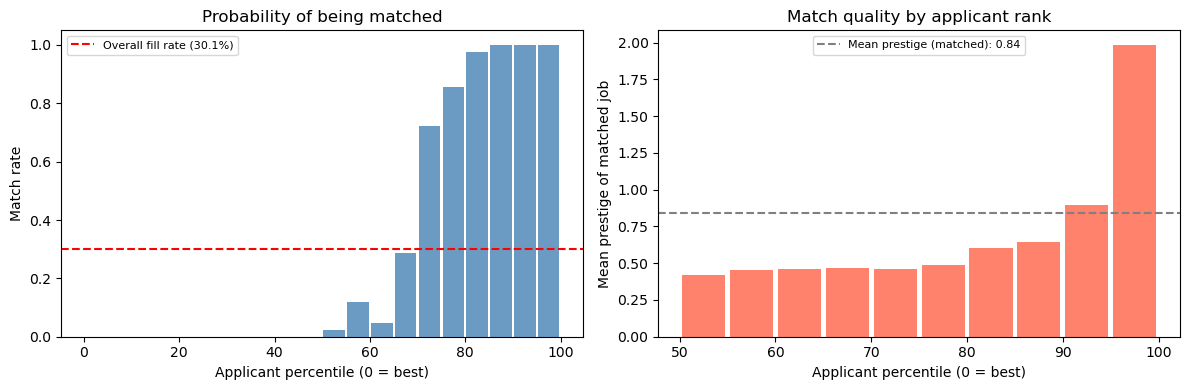

In [16]:
matched_mask   = match_a != -1
student_mask   = np.array([l == 'student' for l in labels])
postdoc_mask   = np.array([l == 'postdoc' for l in labels])

n_stu_matched  = (matched_mask & student_mask).sum()
n_pdc_matched  = (matched_mask & postdoc_mask).sum()

print(f"Students matched : {n_stu_matched} / {N_STUDENT_APPLYING}  "
      f"({n_stu_matched/N_STUDENT_APPLYING:.1%})")
print(f"Postdocs matched : {n_pdc_matched} / {N_POSTDOC_APPLYING}  "
      f"({n_pdc_matched/N_POSTDOC_APPLYING:.1%})")

# Percentile rank of each applicant (0 = best)
pct_ranks = np.arange(n_applicants) / n_applicants * 100

# Prestige of matched job, NaN for unmatched
matched_prestige = np.where(
    matched_mask,
    prestige[np.where(matched_mask, match_a, 0)],
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: match rate by percentile bin
ax = axes[0]
bins = np.linspace(0, 100, 21)
centres = 0.5 * (bins[:-1] + bins[1:])
match_rate_by_pct = [
    matched_mask[(pct_ranks >= b0) & (pct_ranks < b1)].mean()
    for b0, b1 in zip(bins[:-1], bins[1:])
]
ax.bar(centres, match_rate_by_pct, width=4.5, color='steelblue', alpha=0.8)
ax.set_xlabel('Applicant percentile (0 = best)')
ax.set_ylabel('Match rate')
ax.set_title('Probability of being matched')
ax.set_ylim(0, 1.05)
ax.axhline(N_POSITIONS / n_applicants, color='red', linestyle='--',
           label=f'Overall fill rate ({N_POSITIONS/n_applicants:.1%})')
ax.legend(fontsize=8)

# Right: prestige of matched job by percentile
ax = axes[1]
bin_prestiges = []
for b0, b1 in zip(bins[:-1], bins[1:]):
    mask  = (pct_ranks >= b0) & (pct_ranks < b1) & matched_mask
    bin_prestiges.append(np.nanmean(matched_prestige[mask]) if mask.any() else np.nan)
ax.bar(centres, bin_prestiges, width=4.5, color='tomato', alpha=0.8)
ax.axhline(np.nanmean(matched_prestige), color='gray', linestyle='--',
           label=f'Mean prestige (matched): {np.nanmean(matched_prestige):.2f}')
ax.set_xlabel('Applicant percentile (0 = best)')
ax.set_ylabel('Mean prestige of matched job')
ax.set_title('Match quality by applicant rank')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 7 — The Effect of Number of Applications

One of the most practically useful questions: **how does the number of applications affect outcomes?**

In GS this has a clean interpretation: applying to more jobs extends the preference list, giving the algorithm more options to find a stable match. But it also floods job pools, making each pool more competitive.

We run multiple markets sweeping over both applicant rank (student percentile) and application count, and record match rates — directly analogous to our injected-candidate sweep.

In [17]:
def run_gs_market(fixed_pcts=None, fixed_n_apps=None, n_markets=30, seed_offset=0):
    """
    Run n_markets GS markets.  If fixed_pcts / fixed_n_apps are given,
    inject one test candidate per (pct, n_apps) pair; all others draw
    application counts from the lognormal.

    Returns list of per-market result dicts for the injected candidates.
    """
    mean_postdoc = np.log(np.exp(MEAN_APPLICATIONS) / 2)
    max_skill_global = None   # recomputed per market

    all_raw = []

    for m in range(n_markets):
        np.random.seed(seed_offset + m)

        sk, lb = draw_skills()
        max_sk = max(abs(sk))
        pres   = build_prestige()
        na     = len(sk)

        student_skills_sorted = sorted(
            [sk[i] for i in range(na) if lb[i] == 'student'], reverse=True
        )
        n_stu = len(student_skills_sorted)

        # Build application counts (and inject fixed candidates)
        n_apps_arr = np.zeros(na, dtype=int)
        injected   = {}   # idx -> (pct, n_apps)

        for i in range(na):
            if lb[i] == 'postdoc':
                n_apps_arr[i] = max(1, int(np.random.lognormal(
                    mean_postdoc, SIGMA_APPLICATIONS)))
            else:
                n_apps_arr[i] = max(1, int(np.random.lognormal(
                    MEAN_APPLICATIONS, SIGMA_APPLICATIONS)))

        # Inject fixed candidates (override skill and n_apps)
        if fixed_pcts and fixed_n_apps:
            inject_idx = 0
            for pct in fixed_pcts:
                target_skill = student_skills_sorted[int(pct / 100 * n_stu)]
                for n_ap in fixed_n_apps:
                    # Find insertion index (closest skill match)
                    diffs = np.abs(sk - target_skill)
                    best  = int(np.argmin(diffs))
                    # Override that applicant's n_apps (non-destructively track)
                    injected[best] = (pct, n_ap)
                    n_apps_arr[best] = n_ap

        # Build pools and preference lists
        pools_m   = [[] for _ in range(N_POSITIONS)]
        a_prefs_m = [None] * na

        for i in range(na):
            k = min(n_apps_arr[i], N_POSITIONS)
            beta   = 0.5 - SELF_AWARENESS * sk[i] / max_sk
            logits = beta * pres
            logits -= logits.max()
            probs   = np.exp(logits); probs /= probs.sum()
            chosen  = np.random.choice(N_POSITIONS, size=k, replace=False, p=probs)
            for j in chosen:
                pools_m[j].append(i)
            noise = np.random.normal(0, 0.05, k)
            a_prefs_m[i] = list(chosen[np.argsort(-(pres[chosen] + noise))])

        j_prefs_m = [mallows_rank(pool, STOCHASTICITY) for pool in pools_m]

        # Run GS
        ma, mj, _ = gale_shapley(a_prefs_m, j_prefs_m)

        # Record injected results
        for idx, (pct, n_ap) in injected.items():
            matched   = ma[idx] != -1
            pres_val  = float(pres[ma[idx]]) if matched else None
            all_raw.append({
                'student_percentile': pct,
                'n_applications':     n_ap,
                'matched':            matched,
                'matched_prestige':   pres_val,
            })

    return all_raw


PERCENTILES_SWEEP = [5, 10, 25, 50, 75]
N_APPS_SWEEP      = [5, 10, 15, 20, 30, 40, 60]
N_MARKETS         = 80

print(f"Running {N_MARKETS} markets × {len(PERCENTILES_SWEEP)} percentiles "
      f"× {len(N_APPS_SWEEP)} app counts ...")
raw_sweep = run_gs_market(
    fixed_pcts   = PERCENTILES_SWEEP,
    fixed_n_apps = N_APPS_SWEEP,
    n_markets    = N_MARKETS,
    seed_offset  = 100,
)
print(f"Done. {len(raw_sweep):,} records collected.")

Running 80 markets × 5 percentiles × 7 app counts ...


KeyboardInterrupt: 

In [ ]:
# ── Aggregate: match rate per (pct, n_apps) cell ─────────────────────────
from collections import defaultdict

cells = defaultdict(list)
for r in raw_sweep:
    cells[(r['student_percentile'], r['n_applications'])].append(r['matched'])

match_rate = {
    (pct, n): np.mean(vals)
    for (pct, n), vals in cells.items()
}

# ── Plot: match rate vs n_apps, one curve per percentile ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))
cmap    = plt.cm.viridis
colors  = cmap(np.linspace(0.1, 0.9, len(PERCENTILES_SWEEP)))

for pct, color in zip(PERCENTILES_SWEEP, colors):
    rates = [match_rate.get((pct, n), np.nan) for n in N_APPS_SWEEP]
    ax.plot(N_APPS_SWEEP, [r * 100 for r in rates], 'o-',
            color=color, label=f'pct={pct}%', linewidth=2, markersize=5)

for prob, ls in [(50, '--'), (75, '-.'), (90, ':')]:
    ax.axhline(prob, color='gray', linewidth=0.8, linestyle=ls, alpha=0.6)
    ax.text(N_APPS_SWEEP[-1] + 0.5, prob, f'{prob}%', va='center',
            fontsize=8, color='gray')

ax.set_xlabel('Number of applications sent')
ax.set_ylabel('Match rate (%)')
ax.set_title('GS match rate by applicant rank and application count')
ax.legend(title='Student percentile\n(0% = best)', fontsize=8)
ax.set_ylim(0, 105)
ax.set_xlim(0, max(N_APPS_SWEEP) + 5)
plt.tight_layout()
plt.show()

## Step 8 — Minimum Applications for Target Match Probability

Same table format as our simulation, for direct comparison.

In [ ]:
def isotonic_increasing(y):
    """PAVA — returns non-decreasing array."""
    y      = np.array(y, dtype=float).copy()
    blocks = [[i, i, y[i]] for i in range(len(y))]
    i = 0
    while i < len(blocks) - 1:
        if blocks[i][2] > blocks[i+1][2]:
            s, e = blocks[i][0], blocks[i+1][1]
            blocks[i] = [s, e, float(y[s:e+1].mean())]
            blocks.pop(i+1)
            if i > 0: i -= 1
        else:
            i += 1
    result = np.empty(len(y))
    for s, e, mn in blocks:
        result[s:e+1] = mn
    return result


def find_crossing(n_grid, rates, target):
    smoothed = isotonic_increasing(rates)
    for n, r in zip(n_grid, smoothed):
        if r >= target:
            return n
    return None


TARGET_PROBS = [50, 75, 90, 95]
MAX_APPS     = 200

def fmt(v):
    return f'>{MAX_APPS}' if v is None else str(v)

col_headers = [f'pct={p}%' for p in PERCENTILES_SWEEP]
header    = '| Target | ' + ' | '.join(col_headers) + ' |'
separator = '| --- | '   + ' | '.join(['---'] * len(PERCENTILES_SWEEP)) + ' |'

print('\n### GS: minimum applications for target match probability\n')
print(header)
print(separator)
for prob in TARGET_PROBS:
    cells_row = []
    for pct in PERCENTILES_SWEEP:
        rates = [match_rate.get((pct, n), np.nan) for n in N_APPS_SWEEP]
        cells_row.append(fmt(find_crossing(N_APPS_SWEEP, rates, prob / 100)))
    print(f'| P={prob}% | ' + ' | '.join(cells_row) + ' |')

## Step 9 — Job-Proposing GS: The Other Extreme

For completeness, let's also run the **job-proposing** version. This is:
- **Job-optimal**: every job gets the best applicant it can in any stable matching.
- **Applicant-pessimal**: every applicant gets the *worst* stable partner.

In theory, the two versions can produce different matchings. In practice, when both sides have similar preferences (skill ≈ desirability), the two matchings tend to coincide. Let's check.

In [ ]:
def gale_shapley_job_proposing(applicant_prefs, job_prefs):
    """
    Job-proposing Gale-Shapley (roles of applicants and jobs swapped).
    """
    n_a = len(applicant_prefs)
    n_j = len(job_prefs)

    # Applicant ranking lookup: applicant_rank[a][j] = how much a likes j
    applicant_rank = [dict() for _ in range(n_a)]
    for a, ranked in enumerate(applicant_prefs):
        for pos, j in enumerate(ranked):
            applicant_rank[a][j] = pos

    match_a   = [-1] * n_a
    match_j   = [-1] * n_j
    next_prop = [0]  * n_j      # jobs propose

    free_jobs = list(range(n_j))

    while free_jobs:
        next_free = []
        for j in free_jobs:
            if next_prop[j] >= len(job_prefs[j]):
                continue    # job stays unfilled

            a = job_prefs[j][next_prop[j]]
            next_prop[j] += 1

            # Applicant only considers j if it applied there
            if j not in applicant_rank[a]:
                next_free.append(j)   # applicant ignores the offer
                continue

            if match_a[a] == -1:
                match_a[a] = j
                match_j[j] = a
            else:
                current_j      = match_a[a]
                rank_new       = applicant_rank[a].get(j,         float('inf'))
                rank_current   = applicant_rank[a].get(current_j, float('inf'))
                if rank_new < rank_current:
                    # Applicant prefers new job
                    match_a[a]       = j
                    match_j[j]       = a
                    match_j[current_j] = -1
                    next_free.append(current_j)
                else:
                    next_free.append(j)

        free_jobs = [j for j in next_free
                     if next_prop[j] < len(job_prefs[j])]

    return np.array(match_a), np.array(match_j)


match_a_jp, match_j_jp = gale_shapley_job_proposing(applicant_prefs, job_prefs)

# Compare the two matchings
same_match      = np.sum((match_a == match_a_jp) & (match_a != -1))
matched_ap      = np.sum(match_a    != -1)
matched_jp      = np.sum(match_a_jp != -1)

pres_ap = prestige[match_a[match_a != -1]]
pres_jp = prestige[match_a_jp[match_a_jp != -1]]

print(f"Applicant-proposing: {matched_ap} matched, mean prestige = {pres_ap.mean():.3f}")
print(f"Job-proposing      : {matched_jp} matched, mean prestige = {pres_jp.mean():.3f}")
print(f"Identical pairs    : {same_match} / {min(matched_ap, matched_jp)}")
print()

# Show prestige difference for matched applicants in both
both_matched = (match_a != -1) & (match_a_jp != -1)
pres_diff = prestige[match_a[both_matched]] - prestige[match_a_jp[both_matched]]
print(f"For applicants matched in both:")
print(f"  Mean prestige advantage of applicant-proposing: {pres_diff.mean():.4f}")
print(f"  (positive = applicant-proposing gives better jobs for applicants)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pres_diff[pres_diff != 0], bins=30, color='steelblue', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Prestige(applicant-proposing) − Prestige(job-proposing)')
ax.set_ylabel('Count')
ax.set_title('Difference in matched job prestige between the two GS versions')
plt.tight_layout()
plt.show()

## Step 10 — GS vs. the Simulation: Key Differences

Let's summarise what GS tells us, and where it diverges from the round-based simulation.

### What GS guarantees that the simulation does not

1. **Stability** — the simulation has no stability guarantee. An applicant might accept a job early in round 1 and later discover that a better job would have preferred them.
2. **Applicant-optimality** — in the simulation, the order in which jobs make offers matters a lot. An applicant unlucky enough to be offered their 3rd-choice job before their 1st-choice offer arrives must accept or hold.
3. **Strategy-proofness** — in GS, there is no incentive to misreport preferences. In the simulation, applying strategically (e.g. to more jobs, or to different tiers) can affect outcomes.

### What the simulation captures that GS does not

1. **Incomplete information** — applicants don't know how they rank at each job. GS requires full preference lists.
2. **Sequential dynamics** — real markets unfold over time. GS is a one-shot simultaneous process.
3. **Second calls** — when a job exhausts its applicant pool, it can reach out beyond its original pool. GS has no such mechanism.
4. **Variable application counts** — GS preference lists are fixed; the simulation allows application counts to vary and respond to second calls.

### Practical implication

The GS match rate is an **upper bound on what a perfectly coordinated market could achieve** given the same preference structure and application decisions. If the simulation's match rate is close to GS, friction is low. If it's substantially lower, the sequential dynamics are costing applicants significantly.

In [ ]:
# ── Summary statistics side-by-side ──────────────────────────────────────
# Run GS on the preference lists we already built
ma_final, mj_final, gs_stats = gale_shapley(applicant_prefs, job_prefs)

stu_matched = ((ma_final != -1) & student_mask).sum()
pdc_matched = ((ma_final != -1) & postdoc_mask).sum()

print("\n" + "=" * 55)
print("  COMPARISON: Gale-Shapley vs. Simulation (typical run)")
print("=" * 55)
print(f"{'Metric':<35} {'GS':>8} {'Sim (typical)':>14}")
print("-" * 55)
print(f"{'Jobs filled':<35} {gs_stats['jobs_filled']:>8} {'~256':>14}")
print(f"{'Students placed':<35} {stu_matched:>8} {'~177':>14}")
print(f"{'Postdocs placed':<35} {pdc_matched:>8} {'~79':>14}")
print(f"{'Student placement rate':<35} {stu_matched/N_STUDENT_APPLYING:>8.1%} {'~24%':>14}")
print(f"{'Postdoc placement rate':<35} {pdc_matched/N_POSTDOC_APPLYING:>8.1%} {'~79%':>14}")
print(f"{'Mean prestige (placed)':<35} {np.nanmean(matched_prestige):>8.3f} {'varies':>14}")
print("=" * 55)
print()
print("Notes:")
print("  GS: applicant-proposing, preference lists limited to applied-to jobs.")
print("  Sim: round-based, with second calls and sequential acceptance.")
print("  Postdoc rates differ because GS has no second-call mechanism —")
print("  jobs with empty pools simply go unfilled.")

## Summary

The Gale-Shapley algorithm provides a clean theoretical benchmark for the postdoc job market:

- **It always finds a stable matching** — no pair of applicant and job would mutually prefer each other over their assigned partners.
- **Applicant-proposing GS is applicant-optimal** — the best possible stable outcome for applicants. The simulation, being sequential with incomplete information, will generally fall short of this.
- **More applications help, but with diminishing returns** — especially for lower-ranked applicants who need volume to compensate for weaker skill signals.
- **The two GS versions (applicant- vs job-proposing) converge substantially** in this market, because skill and prestige are correlated — high-skill applicants and prestigious jobs tend to match regardless of who proposes.

The main practical takeaway: the GS match rates set a ceiling on what any market mechanism could achieve. Comparing these to the simulation's rates quantifies how much the real market's friction (sequential rounds, second calls, incomplete information) costs.